In [22]:
%reload_ext autoreload
%autoreload 2

import sys
import os

cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)

# Import packages that will be used
import c2qa
from custom_gates import state_transfer,shors,state_generation
import features
import numpy as np
import matplotlib.pyplot as plt
from qiskit import ClassicalRegister, visualization, AncillaRegister,QuantumRegister
from qiskit_aer.noise import NoiseModel, amplitude_damping_error
from qiskit.quantum_info import state_fidelity, Statevector
from qiskit.quantum_info.operators import Operator
from qiskit.quantum_info.operators.predicates import is_unitary_matrix
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import UnitaryGate
from qiskit.circuit.library.standard_gates import HGate
from math import pi, ceil
import scipy
from c2qa.operators import CVOperators
from c2qa.qumoderegister import QumodeRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from c2qa.parameterized_unitary_gate import ParameterizedUnitaryGate
from qutip import *

In [2]:
cutoff = 2**6
osc_init = coherent(cutoff,-2) + coherent(cutoff,2)

In [3]:
Ust = state_transfer.dv2cv_st_non_abelian(0.29,4,cutoff)
Ust1 = Ust.dag()

In [25]:
def apply_basis_transformation(circuit, qbr1):
    num_qubits = len(qbr1)
    for i in range(num_qubits):
        circuit.h(qbr1[i])
        if i == num_qubits - 1:  # MSB
            circuit.x(qbr1[i])
            circuit.z(qbr1[i])
        elif i == 0:  # LSB
            circuit.z(qbr1[i])
        else:  # Middle qubits
            circuit.x(qbr1[i])
            
from custom_gates import state_transfer

# Initialize the circuit
qbm = 4
lmbda = 0.29
cutoff = 2**6
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode=6,name='qmode')
qbr1 = QuantumRegister(4)
cr1 = ClassicalRegister(4)
circuit = c2qa.CVCircuit(qmr, qbr1, cr1)

# Initialize the CV qumode
circuit.cv_initialize(1, qmr[0])  # initializing qumode in Fock State 1
circuit.barrier(label='')

# Add the CV-to-DV transfer gate
for j in range(1,qbm+1):
        V_j = state_transfer.Vj(lmbda,j,4,cutoff)
        gate1 = UnitaryGate(V_j.full(), label=f'V{j}')
        circuit.append(gate1, qmr[:] + qbr1[:])  # adding custom gate : Conditional displacement in p direction
        
        W_j = state_transfer.Wj(lmbda,j,4,cutoff)
        gate1 = UnitaryGate(W_j.full(), label=f'W{j}')
        circuit.append(gate1, qmr[:] + qbr1[:])  # adding custom gate : Conditional displacement in x direction


circuit.barrier()

# Apply basis transformation
apply_basis_transformation(circuit, qbr1)

circuit.barrier()

# Simulate and measure
for i in range(len(qbr1)):
    circuit.measure(qbr1[i], cr1[-(i + 1)])

# state1, result, _ = c2qa.util.simulate(circuit, shots=1024)
# plot_histogram(result.get_counts())

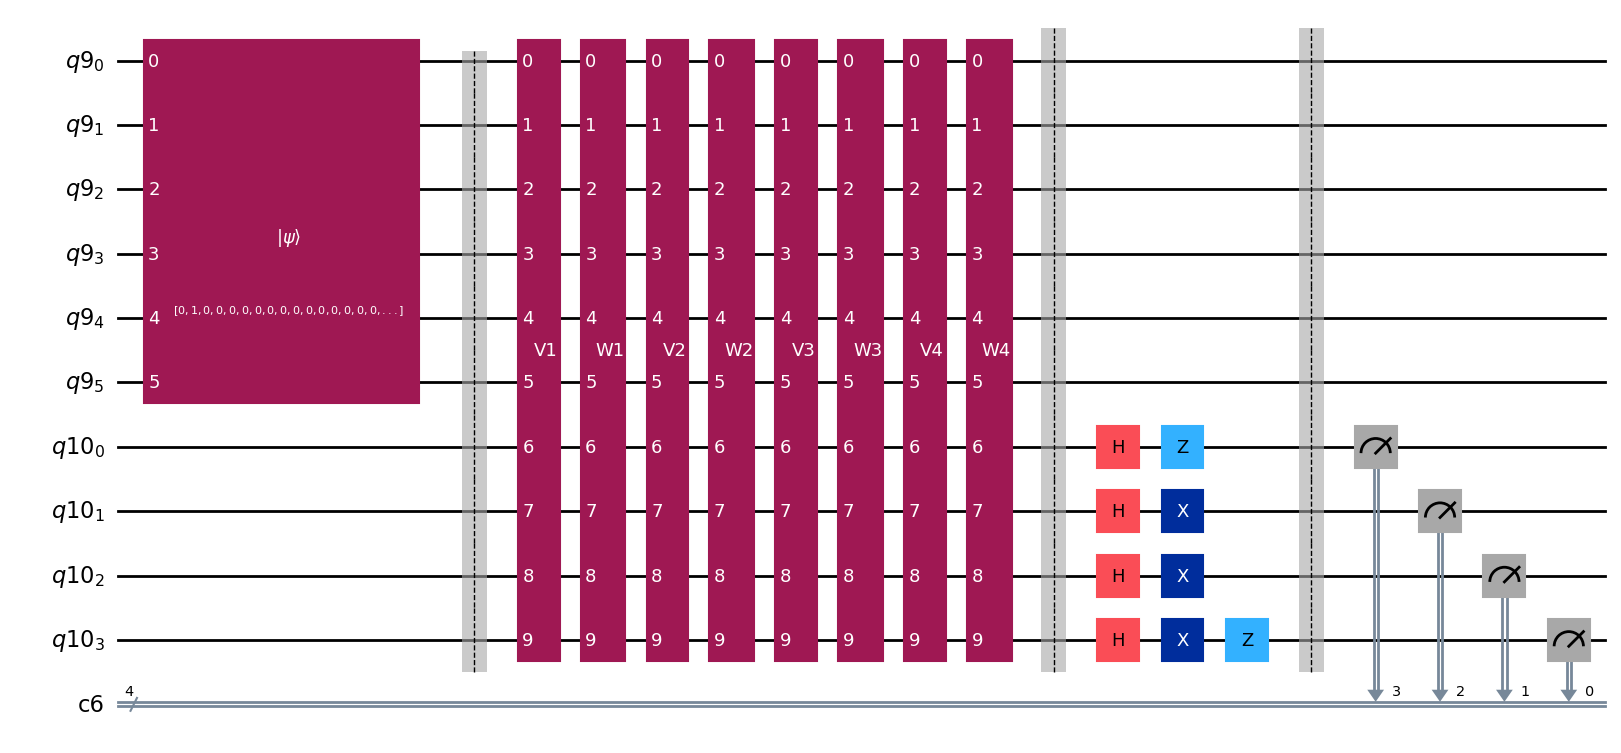

In [19]:
circuit.draw('mpl')

In [30]:
qmr1 = c2qa.QumodeRegister(num_qumodes=3, num_qubits_per_qumode=int(np.ceil(np.log2(cutoff))), name='qmode')
qbr = QuantumRegister(1)
cr = ClassicalRegister(1)
R_gate = shors.translation_R(cutoff, 15)
M_gate = shors.multiplication(cutoff, 15)
alpha = np.sqrt(np.pi)
delta = 0.222
circuit_shors = c2qa.CVCircuit(qmr1, qbr, cr)

for i in range(3):
            circuit_shors.cv_sq(-np.log(delta), qmr1[i])

for k in range(1, 9):
            circuit_shors.cv_c_d(alpha, qmr1[0], qbr[0])
            Uxk = state_generation.Ux_operator(cutoff, alpha, 4 * k, delta)
            Ux_gate = UnitaryGate(Uxk.full(), label=f'Ux_{k}')
            circuit_shors.append(Ux_gate, qmr1[0] + qbr[:])

for k in range(1, 9):
            circuit_shors.cv_c_d(alpha, qmr1[1], qbr[0])
            Uxk = state_generation.Ux_operator(cutoff, alpha, 4 * k, delta)
            Ux_gate = UnitaryGate(Uxk.full(), label=f'Ux_{k}')
            circuit_shors.append(Ux_gate, qmr1[1] + qbr[:])
            
circuit_shors.append(UnitaryGate(R_gate.full(), label='R'), qmr1[0])
circuit_shors.append(UnitaryGate(M_gate.full(), label=f'M{15}'), qmr1[1])
circuit_shors = shors.U_aNm(cutoff, circuit_shors, qmr1, qbr, 2, 15, 2)


4
2


In [31]:
circuit_metrics_st = features.collect_cvcircuit_metrics(circuit)
circuit_metrics_shor = features.collect_cvcircuit_metrics(circuit_shors)

In [32]:
print(circuit_metrics_st)

{'Qubits': 4, 'Qumodes': 6, 'Qubit Gates': 9, 'Qumode Gates': 0, 'Hybrid Gates': 8, 'Total Gates': 17}


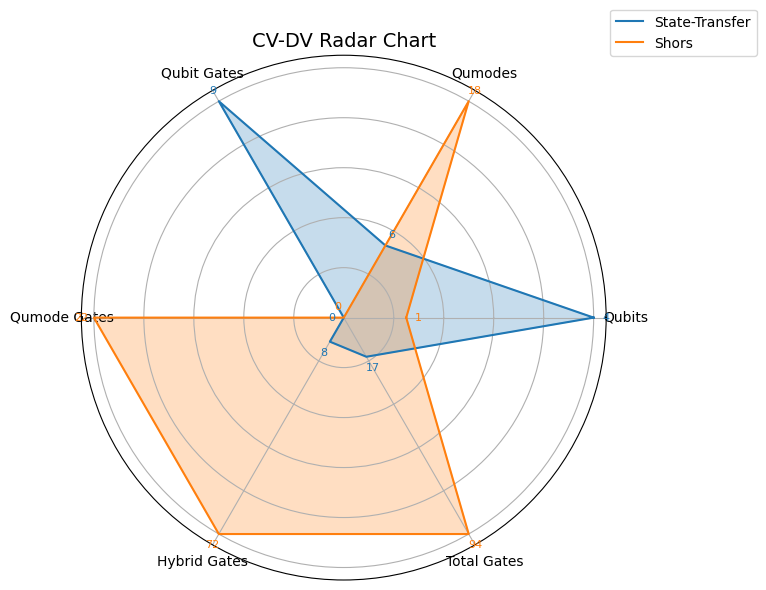

In [33]:
features.plot_radar_metrics([circuit_metrics_st,circuit_metrics_shor],['State-Transfer','Shors'])